# Data Science in Cyber - Final Project
## Network Intrusion Detection with Autoencoders on NSL-KDD

Reproduction of [Steven Foerster tutorial](https://stevenfoerster.com/tutorials/network-intrusion-detection-with-autoencoders/).


In [1]:
import sys
from pathlib import Path
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from src.autoencoder import train_and_evaluate_autoencoder
from src.metrics_utils import classification_report_dict, metrics_to_frame
from src.plotting import plot_confusion_matrices, plot_metric_comparison, plot_reconstruction_error_distribution
from src.preprocessing import RANDOM_STATE, build_feature_matrix, load_nslkdd

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
DATA_DIR = ROOT / 'data'
FIG_DIR = ROOT / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)



## 1. Data Loading and Inspection


In [2]:
train_df = load_nslkdd(DATA_DIR / 'KDDTrain+.txt')
test_df = load_nslkdd(DATA_DIR / 'KDDTest+.txt')
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
display(train_df.head())
display(train_df.dtypes.to_frame('dtype'))



Train shape: (125973, 45)
Test shape: (22544, 45)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level,category,is_attack
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,normal,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,normal,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,DoS,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,normal,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,normal,0


,dtype
duration,int64
protocol_type,str
service,str
flag,str
src_bytes,int64
dst_bytes,int64
land,int64
wrong_fragment,int64
urgent,int64
hot,int64


In [3]:
pd.DataFrame({
    'split': ['train', 'test'],
    'rows': [len(train_df), len(test_df)],
    'attack_rate_%': [round(train_df.is_attack.mean()*100,2), round(test_df.is_attack.mean()*100,2)],
})



,split,rows,attack_rate_%
0,train,125973,46.54
1,test,22544,56.92


### Index and column-name sanity check
NSL-KDD rows are independent connection records. Column names follow the official KDD feature spec and are meaningful for IDS (bytes, flags, host statistics). There is no time-ordered index.


In [4]:
print('Missing values:', train_df.isna().sum().sum())
print('Duplicate rows:', train_df.duplicated().sum())
single_value = train_df.nunique()
display(single_value[single_value <= 1])



Missing values: 0
Duplicate rows: 0


num_outbound_cmds    1
dtype: int64

### Temporal analysis
There is **no global timestamp** in NSL-KDD. duration is per-connection length (seconds), and count/srv_count summarize a 2-second window. We cannot perform meaningful calendar/time-series analysis; only connection-duration distributions are available.


In [5]:
train_df['duration'].describe()



count    125973.00000
mean        287.14465
std        2604.51531
min           0.00000
25%           0.00000
50%           0.00000
75%           0.00000
max       42908.00000
Name: duration, dtype: float64

## 2. Exploratory Data Analysis


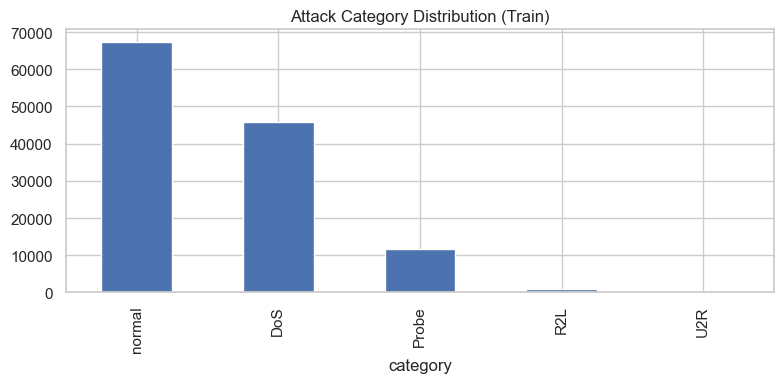

In [6]:
fig, ax = plt.subplots(figsize=(8,4))
train_df['category'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Attack Category Distribution (Train)')
plt.tight_layout(); plt.savefig(FIG_DIR/'category_distribution.png', dpi=150); plt.show()



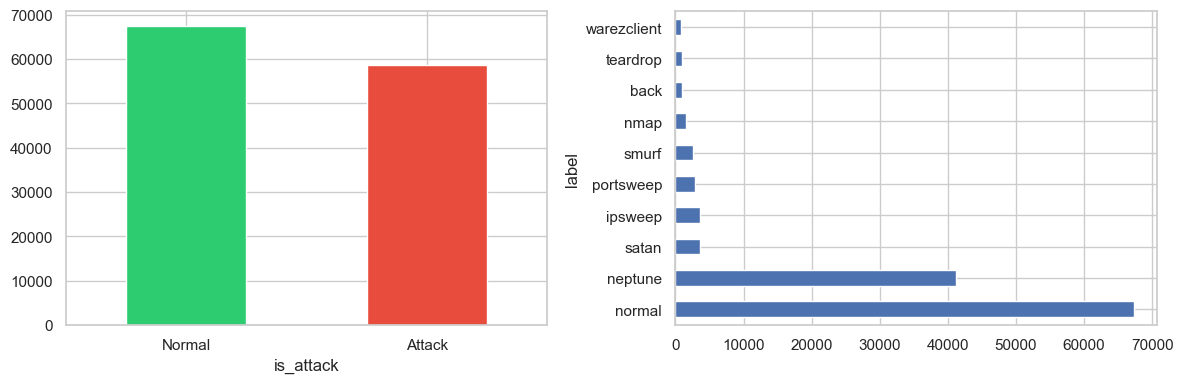

In [7]:
# Class imbalance: missing attacks (FN) is often worse than false alerts (FP) in IDS
fig, ax = plt.subplots(1,2, figsize=(12,4))
train_df['is_attack'].value_counts().plot(kind='bar', ax=ax[0], color=['#2ecc71','#e74c3c'])
ax[0].set_xticklabels(['Normal','Attack'], rotation=0)
train_df['label'].value_counts().head(10).plot(kind='barh', ax=ax[1])
plt.tight_layout(); plt.savefig(FIG_DIR/'class_imbalance.png', dpi=150); plt.show()



In [8]:
# Outlier analysis with IQR on heavy-tailed cyber traffic features
for col in ['src_bytes','dst_bytes','duration']:
    q1,q3 = train_df[col].quantile([0.25,0.75])
    iqr = q3-q1
    upper = q3 + 1.5*iqr
    print(f'{col}: outlier rate={(train_df[col]>upper).mean():.2%}')



src_bytes: outlier rate=10.99%
dst_bytes: outlier rate=18.72%
duration: outlier rate=7.95%


Top Pearson pairs:


num_compromised       num_root                    0.998833
serror_rate           srv_serror_rate             0.993289
rerror_rate           srv_rerror_rate             0.989008
srv_serror_rate       dst_host_srv_serror_rate    0.986252
dst_host_serror_rate  dst_host_srv_serror_rate    0.985052
dtype: float64

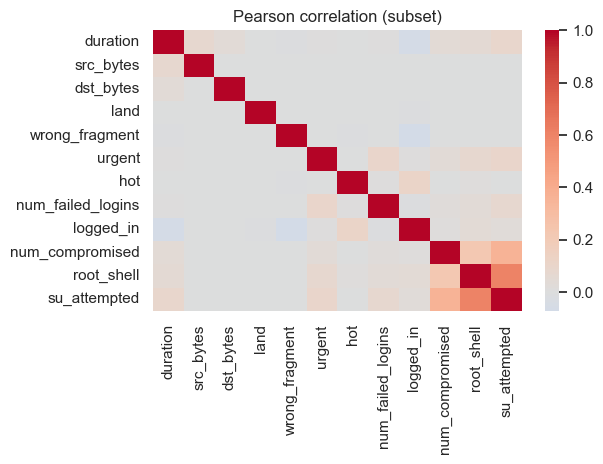

In [9]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if c not in ['difficulty_level','is_attack']]
pearson = train_df[numeric_cols].corr(method='pearson')
spearman = train_df[numeric_cols].corr(method='spearman')
# Pearson: linear relations among rates/counts. Spearman: robust to skewed byte counts.
# Kendall optional for rank consistency; less needed given large n.
kendall = train_df[numeric_cols[:8]].corr(method='kendall')
print('Top Pearson pairs:')
display(pearson.where(np.triu(np.ones(pearson.shape), k=1).astype(bool)).stack().sort_values(ascending=False).head(5))
sns.heatmap(pearson.loc[numeric_cols[:12], numeric_cols[:12]], cmap='coolwarm', center=0)
plt.title('Pearson correlation (subset)'); plt.tight_layout(); plt.savefig(FIG_DIR/'pearson_heatmap.png', dpi=150); plt.show()



category,DoS,Probe,R2L,U2R,normal
protocol_type,,,,,
icmp,0.343,0.499,0.00,0.0,0.158
tcp,0.411,0.057,0.01,0.0,0.522
udp,0.059,0.111,0.00,0.0,0.829


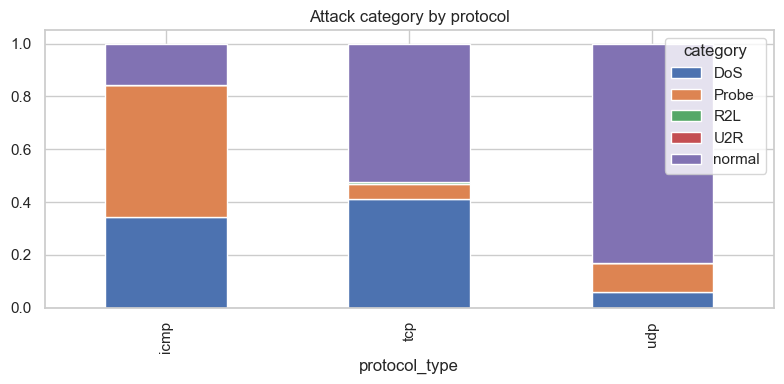

In [10]:
ct = pd.crosstab(train_df['protocol_type'], train_df['category'], normalize='index')
display(ct.round(3))
ct.plot(kind='bar', stacked=True, figsize=(8,4))
plt.title('Attack category by protocol'); plt.tight_layout(); plt.savefig(FIG_DIR/'protocol_crosstab.png', dpi=150); plt.show()



## 3. Feature Engineering


In [11]:
x_train, x_test, feature_cols, scaler = build_feature_matrix(train_df, test_df)
y_train = train_df['is_attack'].to_numpy()
y_test = test_df['is_attack'].to_numpy()
print('Encoded features:', len(feature_cols))



Encoded features: 122


In [12]:
encoded = pd.DataFrame(x_train, columns=feature_cols)
corr_encoded = encoded.corr().abs()
mask = np.triu(np.ones(corr_encoded.shape), k=1).astype(bool)
redundant = corr_encoded.where(mask).stack()
display(redundant[redundant > 0.95].sort_values(ascending=False).head(10))



num_compromised           num_root                    0.998833
serror_rate               srv_serror_rate             0.993289
rerror_rate               srv_rerror_rate             0.989008
srv_serror_rate           dst_host_srv_serror_rate    0.986252
dst_host_serror_rate      dst_host_srv_serror_rate    0.985052
srv_serror_rate           flag_S0                     0.982660
dst_host_srv_serror_rate  flag_S0                     0.981209
serror_rate               dst_host_srv_serror_rate    0.981139
                          dst_host_serror_rate        0.979373
                          flag_S0                     0.979174
dtype: float64

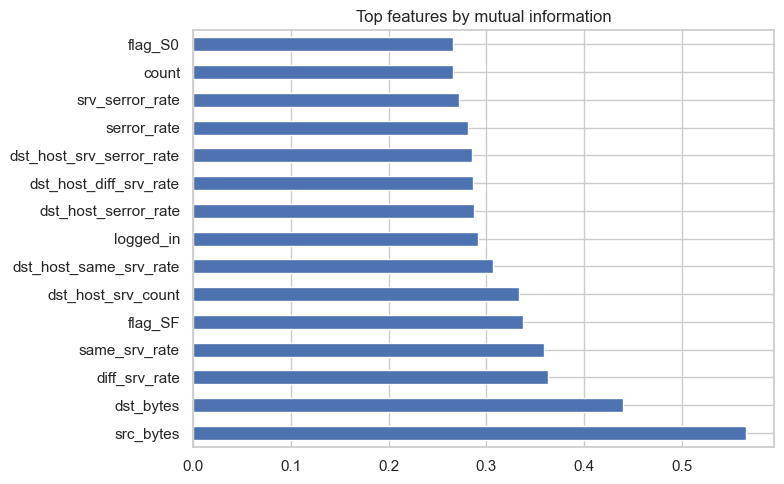

In [13]:
mi = mutual_info_classif(x_train, y_train, random_state=RANDOM_STATE)
pd.Series(mi, index=feature_cols).sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8,5))
plt.title('Top features by mutual information'); plt.tight_layout(); plt.savefig(FIG_DIR/'mutual_information.png', dpi=150); plt.show()



## 4. Model Training


In [14]:
x_fit, _, y_fit, _ = train_test_split(x_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train)
models = {
    'logistic_regression': LogisticRegression(max_iter=500, class_weight='balanced', random_state=RANDOM_STATE),
    'random_forest': RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1),
}
fitted = {n: m.fit(x_fit, y_fit) or m for n,m in models.items()}

normal_mask = y_fit == 0
x_normal_all = x_fit[normal_mask]
x_train_normal, x_val_normal = train_test_split(x_normal_all, test_size=0.2, random_state=RANDOM_STATE)

iforest = IsolationForest(n_estimators=100, contamination=0.1, random_state=RANDOM_STATE, n_jobs=-1)
iforest.fit(x_train_normal)

_, ae_pred, ae_score, ae_threshold, ae_errors = train_and_evaluate_autoencoder(
    x_train_normal, x_val_normal, x_test, y_test, input_dim=x_train.shape[1]
)



Autoencoder epoch 10/40, train MSE=0.146143


Autoencoder epoch 20/40, train MSE=0.079485


Autoencoder epoch 30/40, train MSE=0.058796


Autoencoder epoch 40/40, train MSE=0.046411


## 5. Evaluation


In [15]:
results = {}
preds = {}
for name, model in fitted.items():
    y_pred = model.predict(x_test)
    y_score = model.predict_proba(x_test)[:,1]
    results[name] = classification_report_dict(y_test, y_pred, y_score)
    preds[name] = y_pred

raw = -iforest.score_samples(x_test)
thr = np.percentile(-iforest.score_samples(x_train_normal), 95)
if_pred = (raw >= thr).astype(int)
if_score = (raw-raw.min())/(raw.max()-raw.min()+1e-9)
results['isolation_forest'] = classification_report_dict(y_test, if_pred, if_score)
results['autoencoder'] = classification_report_dict(y_test, ae_pred, ae_score)
preds['isolation_forest'] = if_pred
preds['autoencoder'] = ae_pred

metrics_df = metrics_to_frame({k:{kk:vv for kk,vv in v.items() if kk!='confusion_matrix'} for k,v in results.items()})
metrics_df.round(4)



,accuracy,precision,recall,f1,f2,mcc,roc_auc,pr_auc
autoencoder,0.8741,0.9256,0.8470,0.8845,0.8616,0.7503,0.9529,0.9521
isolation_forest,0.7811,0.9724,0.6334,0.7671,0.6808,0.6249,0.9453,0.9563
random_forest,0.7716,0.9684,0.6190,0.7552,0.6671,0.6096,0.9604,0.9637
logistic_regression,0.7562,0.9170,0.6285,0.7459,0.6707,0.5618,0.7798,0.8612


In [16]:
plot_reconstruction_error_distribution(ae_errors, y_test, ae_threshold, FIG_DIR/'autoencoder_reconstruction_error.png')
plot_confusion_matrices(y_test, preds, FIG_DIR/'confusion_matrices.png')
plot_metric_comparison(metrics_df, FIG_DIR/'model_metric_comparison.png')
metrics_df.to_csv(ROOT/'results'/'model_comparison.csv')



## 6. Error Analysis
False negatives are dangerous in IDS because undetected intrusions may persist. False positives cause alert fatigue. The autoencoder threshold controls this trade-off.


In [17]:
rf_pred = preds['random_forest']
err = test_df.copy(); err['pred'] = rf_pred
fn = err[(err.is_attack==1)&(err.pred==0)]
fp = err[(err.is_attack==0)&(err.pred==1)]
print('Top FN categories:'); display(fn['category'].value_counts().head())
print('Top FP labels:'); display(fp['label'].value_counts().head())



Top FN categories:


category
R2L      2624
DoS      1476
Probe     614
U2R       176
Name: count, dtype: int64

Top FP labels:


label
normal    259
Name: count, dtype: int64

## 7. Executive Summary
We reproduced the PyTorch autoencoder IDS pipeline and compared it with classical baselines. Reconstruction error separates most attacks from normal traffic. The autoencoder achieved the strongest F1/recall among tested models, while Random Forest still leads ROC-AUC when labels are used.
